C:\Users\DELL\AppData\Local\Temp\ipykernel_42204\3809050649.py:8: DtypeWarning: Columns (0: order_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


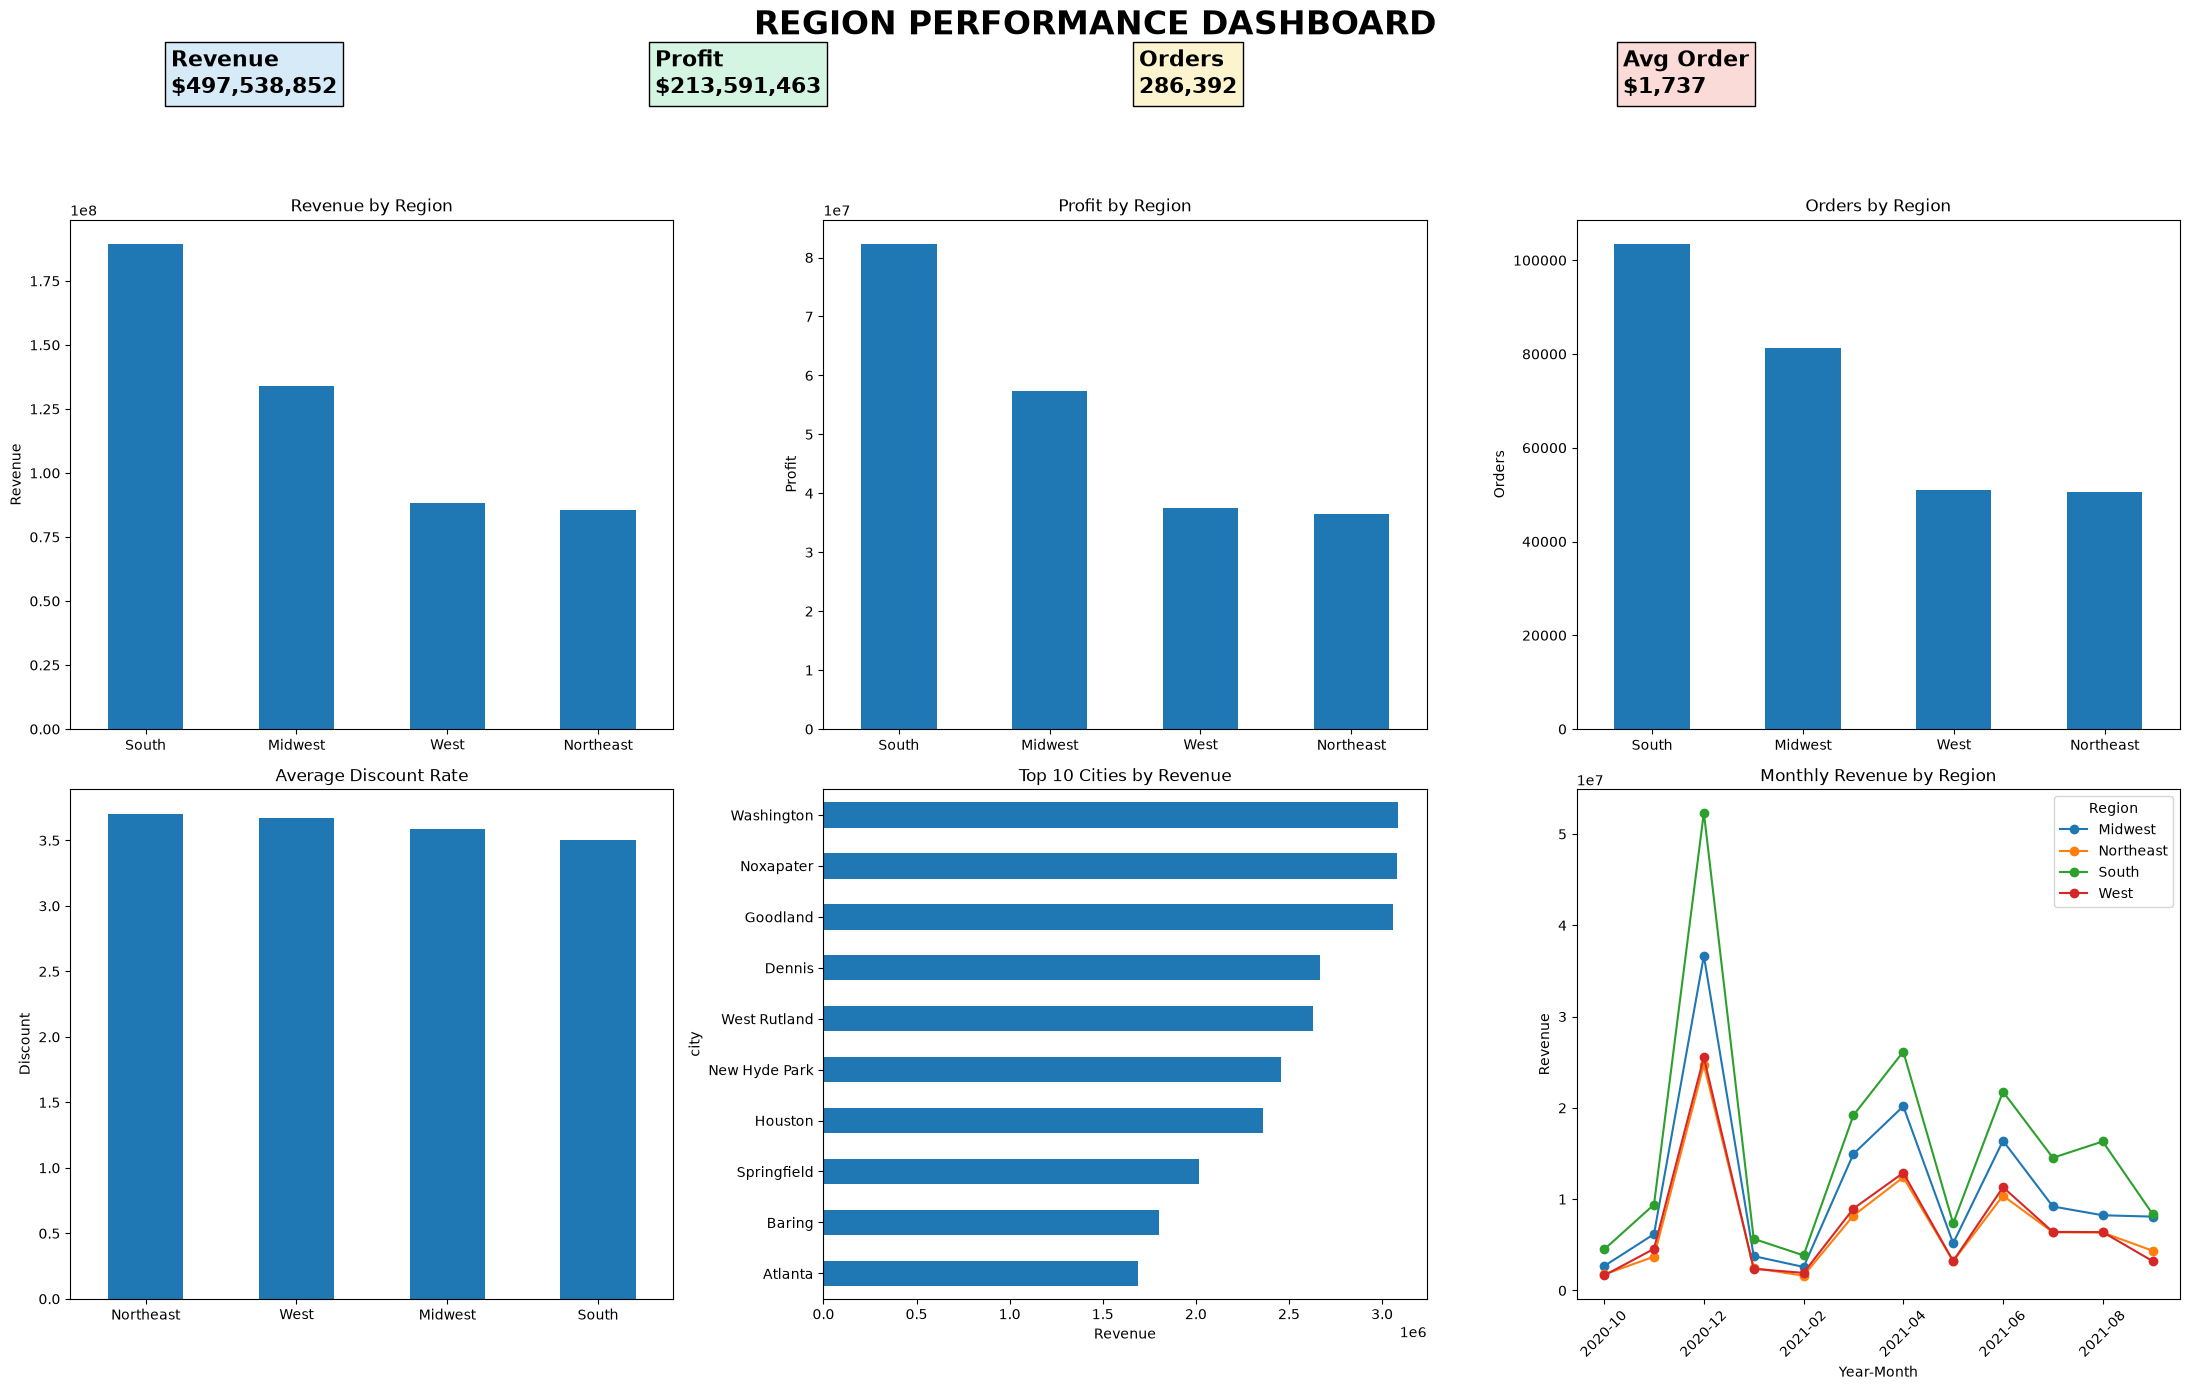

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Đọc dữ liệu
# =====================================================
file_path = r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv"      # Thay bằng đường dẫn nếu cần
df = pd.read_csv(file_path)

# =====================================================
# Kiểm tra các cột cần thiết
# =====================================================
required_columns = [
    'region',
    'city',
    'revenue',
    'profit',
    'discount_rate',
    'year_month'
]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Không tìm thấy cột: {col}")

# =====================================================
# KPI
# =====================================================
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()
total_orders = len(df)
avg_order = df['revenue'].mean()

# =====================================================
# Tổng hợp dữ liệu
# =====================================================

# Doanh thu theo Region
region_revenue = (
    df.groupby('region')['revenue']
      .sum()
      .sort_values(ascending=False)
)

# Lợi nhuận theo Region
region_profit = (
    df.groupby('region')['profit']
      .sum()
      .sort_values(ascending=False)
)

# Số đơn hàng
region_orders = (
    df.groupby('region')
      .size()
      .sort_values(ascending=False)
)

# Giảm giá trung bình
region_discount = (
    df.groupby('region')['discount_rate']
      .mean()
      .sort_values(ascending=False)
)

# Top 10 thành phố doanh thu cao
top_city = (
    df.groupby('city')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Doanh thu theo tháng và Region
monthly_region = (
    df.groupby(['year_month', 'region'])['revenue']
      .sum()
      .unstack(fill_value=0)
)

# =====================================================
# Tạo Dashboard
# =====================================================

fig = plt.figure(figsize=(22,14))

fig.suptitle(
    "REGION PERFORMANCE DASHBOARD",
    fontsize=24,
    fontweight='bold',
    y=0.99
)

# =====================================================
# KPI
# =====================================================

fig.text(
    0.08,
    0.93,
    f"Revenue\n${total_revenue:,.0f}",
    fontsize=16,
    weight='bold',
    bbox=dict(facecolor='#D6EAF8', edgecolor='black')
)

fig.text(
    0.30,
    0.93,
    f"Profit\n${total_profit:,.0f}",
    fontsize=16,
    weight='bold',
    bbox=dict(facecolor='#D5F5E3', edgecolor='black')
)

fig.text(
    0.52,
    0.93,
    f"Orders\n{total_orders:,}",
    fontsize=16,
    weight='bold',
    bbox=dict(facecolor='#FCF3CF', edgecolor='black')
)

fig.text(
    0.74,
    0.93,
    f"Avg Order\n${avg_order:,.0f}",
    fontsize=16,
    weight='bold',
    bbox=dict(facecolor='#FADBD8', edgecolor='black')
)

# =====================================================
# Biểu đồ 1
# =====================================================
ax1 = plt.subplot(2,3,1)

region_revenue.plot(
    kind='bar',
    ax=ax1
)

ax1.set_title("Revenue by Region")
ax1.set_xlabel("")
ax1.set_ylabel("Revenue")
ax1.tick_params(axis='x', rotation=0)

# =====================================================
# Biểu đồ 2
# =====================================================
ax2 = plt.subplot(2,3,2)

region_profit.plot(
    kind='bar',
    ax=ax2
)

ax2.set_title("Profit by Region")
ax2.set_xlabel("")
ax2.set_ylabel("Profit")
ax2.tick_params(axis='x', rotation=0)

# =====================================================
# Biểu đồ 3
# =====================================================
ax3 = plt.subplot(2,3,3)

region_orders.plot(
    kind='bar',
    ax=ax3
)

ax3.set_title("Orders by Region")
ax3.set_xlabel("")
ax3.set_ylabel("Orders")
ax3.tick_params(axis='x', rotation=0)

# =====================================================
# Biểu đồ 4
# =====================================================
ax4 = plt.subplot(2,3,4)

region_discount.plot(
    kind='bar',
    ax=ax4
)

ax4.set_title("Average Discount Rate")
ax4.set_xlabel("")
ax4.set_ylabel("Discount")
ax4.tick_params(axis='x', rotation=0)

# =====================================================
# Biểu đồ 5
# =====================================================
ax5 = plt.subplot(2,3,5)

top_city.sort_values().plot(
    kind='barh',
    ax=ax5
)

ax5.set_title("Top 10 Cities by Revenue")
ax5.set_xlabel("Revenue")

# =====================================================
# Biểu đồ 6
# =====================================================
ax6 = plt.subplot(2,3,6)

monthly_region.plot(
    ax=ax6,
    marker='o'
)

ax6.set_title("Monthly Revenue by Region")
ax6.set_xlabel("Year-Month")
ax6.set_ylabel("Revenue")
ax6.tick_params(axis='x', rotation=45)
ax6.legend(title="Region")

# =====================================================
# Căn chỉnh
# =====================================================
plt.tight_layout(rect=[0,0,1,0.90])

plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_42204\2789852120.py:5: DtypeWarning: Columns (0: order_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv")


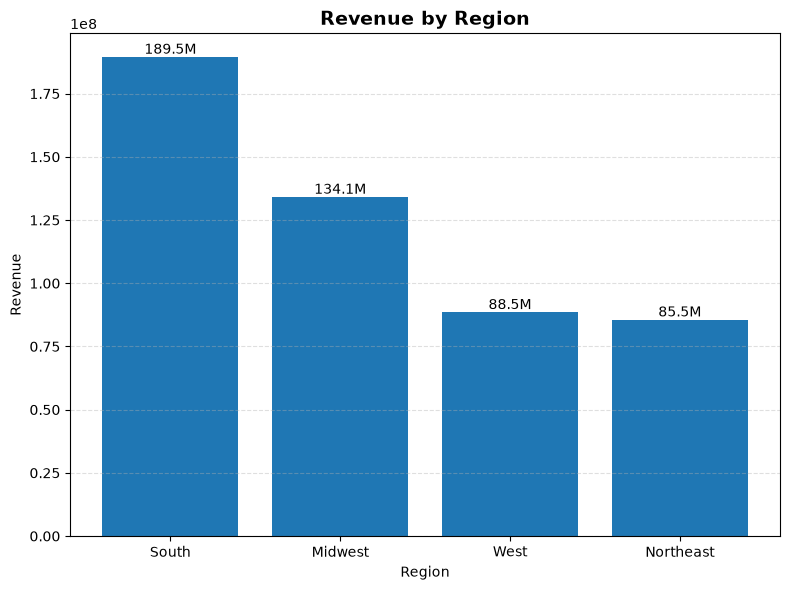

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv(r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv")

# Tổng doanh thu theo khu vực
region_revenue = (
    df.groupby("region")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

bars = plt.bar(
    region_revenue.index,
    region_revenue.values
)

plt.title("Revenue by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Revenue")

# Hiển thị giá trị trên cột
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height()/1e6:.1f}M",
        ha="center",
        va="bottom"
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_42204\2640324241.py:4: DtypeWarning: Columns (0: order_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv")


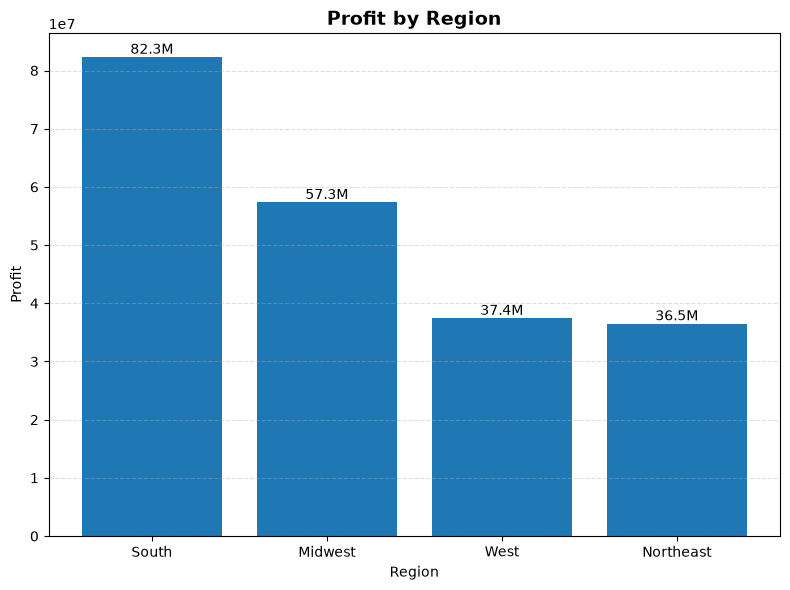

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv")

region_profit = (
    df.groupby("region")["profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

bars = plt.bar(
    region_profit.index,
    region_profit.values
)

plt.title("Profit by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Profit")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height()/1e6:.1f}M",
        ha="center",
        va="bottom"
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_42204\1110233490.py:4: DtypeWarning: Columns (0: order_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv")


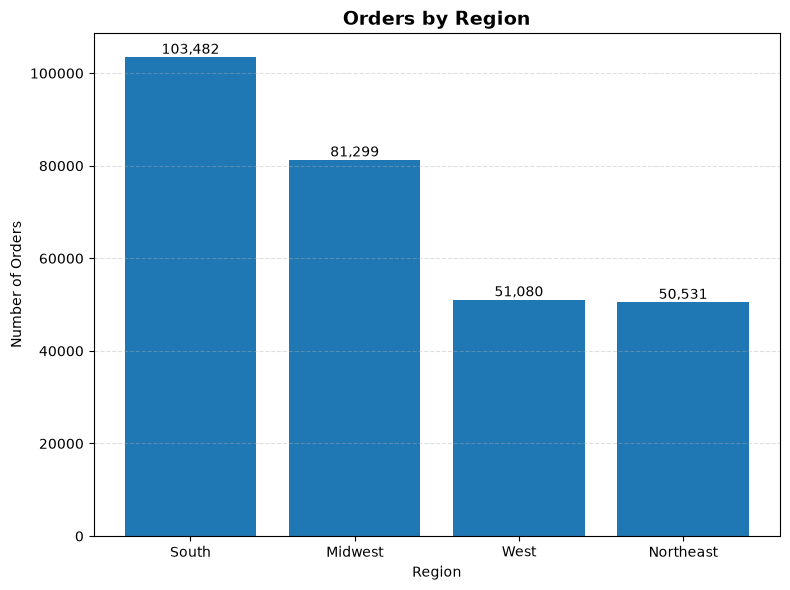

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv")

region_orders = (
    df.groupby("region")
      .size()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

bars = plt.bar(
    region_orders.index,
    region_orders.values
)

plt.title("Orders by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Number of Orders")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_42204\666525739.py:4: DtypeWarning: Columns (0: order_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv")


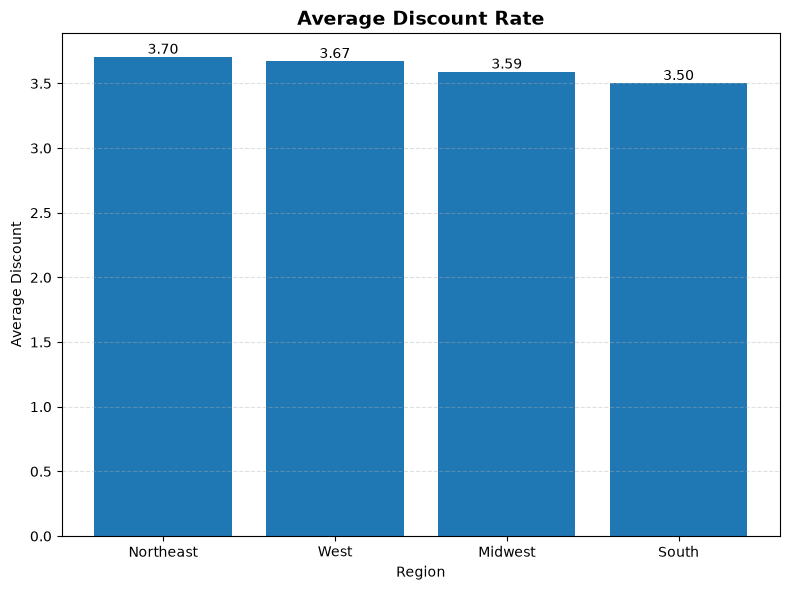

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv")

region_discount = (
    df.groupby("region")["discount_rate"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

bars = plt.bar(
    region_discount.index,
    region_discount.values
)

plt.title("Average Discount Rate", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Average Discount")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_42204\2814247793.py:4: DtypeWarning: Columns (0: order_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv")


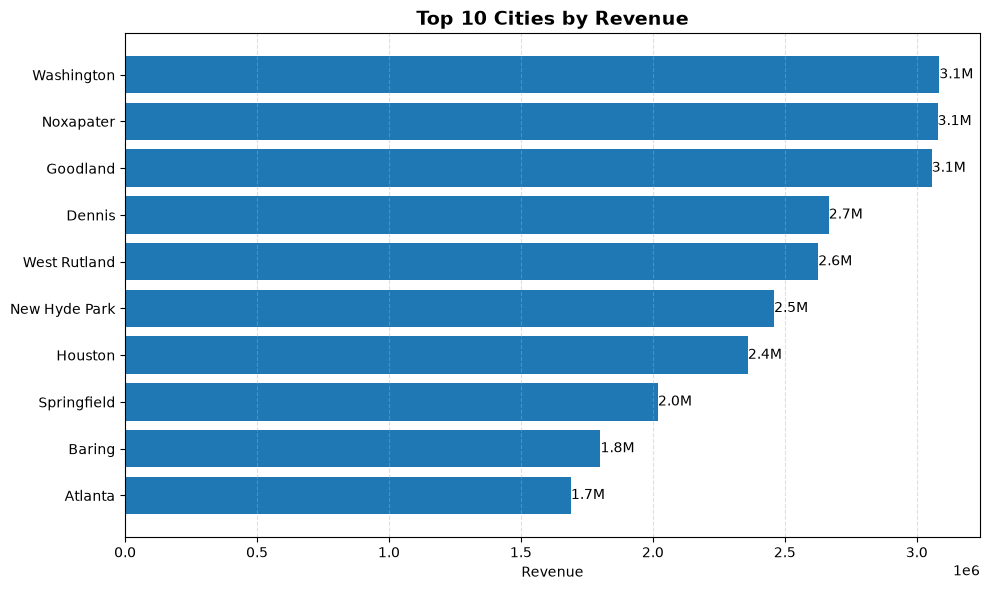

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv")

top_city = (
    df.groupby("city")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_city.index[::-1],
    top_city.values[::-1]
)

plt.title("Top 10 Cities by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue")

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width()/1e6:.1f}M",
        va="center"
    )

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_42204\567537210.py:4: DtypeWarning: Columns (0: order_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv")


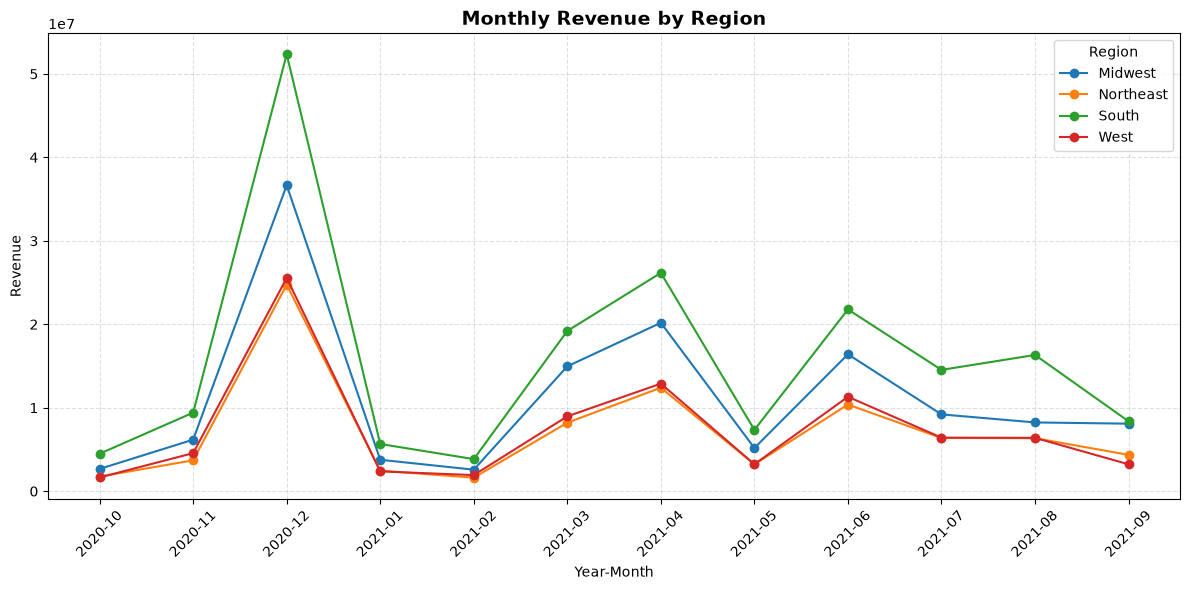

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\PRO_du án tốt nghiệp\data\cleaned\sales_transformed.csv")

monthly_region = (
    df.groupby(["year_month","region"])["revenue"]
      .sum()
      .unstack(fill_value=0)
)

plt.figure(figsize=(12,6))

for region in monthly_region.columns:
    plt.plot(
        monthly_region.index,
        monthly_region[region],
        marker='o',
        label=region
    )

plt.title("Monthly Revenue by Region", fontsize=14, fontweight="bold")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.legend(title="Region")

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()